In [75]:
# SETUP: IMPORTS AND PATHS

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [76]:
# DEFINE PATHS TO DATASETS
CLIMATE_DIR = "v3.5/" # Directory containing climate datasets (e.g., CRUJRA)
CVEG_PATH   = "EDv3_S3_cVeg.nc" # Path to the cVeg dataset (from which AGB will be derived)
YEARS       = range(2001, 2017) # Years to cover (2001-2016 as in iLAMB)



In [77]:

# LOAD A SAMPLE CLIMATE DATASET TO CHECK
ds = xr.open_dataset("v3.5/CRUJRA_v3.5_climate_2001.nc")
print(ds)


<xarray.Dataset> Size: 102MB
Dimensions:               (lat: 360, lon: 720, time: 12)
Coordinates:
  * lat                   (lat) float32 1kB 89.75 89.25 88.75 ... -89.25 -89.75
  * lon                   (lon) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * time                  (time) datetime64[ns] 96B 2001-01-15 ... 2001-12-15
    year                  int64 8B ...
Data variables:
    temperature           (time, lat, lon) float32 12MB ...
    precipitation         (time, lat, lon) float32 12MB ...
    annual_temperature    (lat, lon) float32 1MB ...
    annual_precipitation  (lat, lon) float32 1MB ...
    soil_temp1            (time, lat, lon) float32 12MB ...
    soil_temp2            (time, lat, lon) float32 12MB ...
    soil_temp3            (time, lat, lon) float32 12MB ...
    soil_temp4            (time, lat, lon) float32 12MB ...
    soil_temp5            (time, lat, lon) float32 12MB ...
    soil_temp6            (time, lat, lon) float32 12MB ...


In [78]:
# LOAD CVEG DATASET AND INSEPCT
ds_agb = xr.open_dataset(CVEG_PATH)
cveg   = ds_agb["cVeg"].rename({"latitude": "lat", "longitude": "lon"})
print(cveg)

<xarray.DataArray 'cVeg' (time: 325, lat: 360, lon: 720)> Size: 337MB
[84240000 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * time     (time) datetime64[ns] 3kB 1700-12-15 1701-12-15 ... 2024-12-15
Attributes:
    long_name:  Carbon in Vegetation
    units:      kg m-2


In [79]:
# CONVERT CVEG TO ABOVEGROUND BIOMASS (AGB)
# ED assumes 80% of total vegetation carbon is aboveground biomass 

agb = 0.8 * cveg      # aboveground biomass = 80% of total vegetation carbon

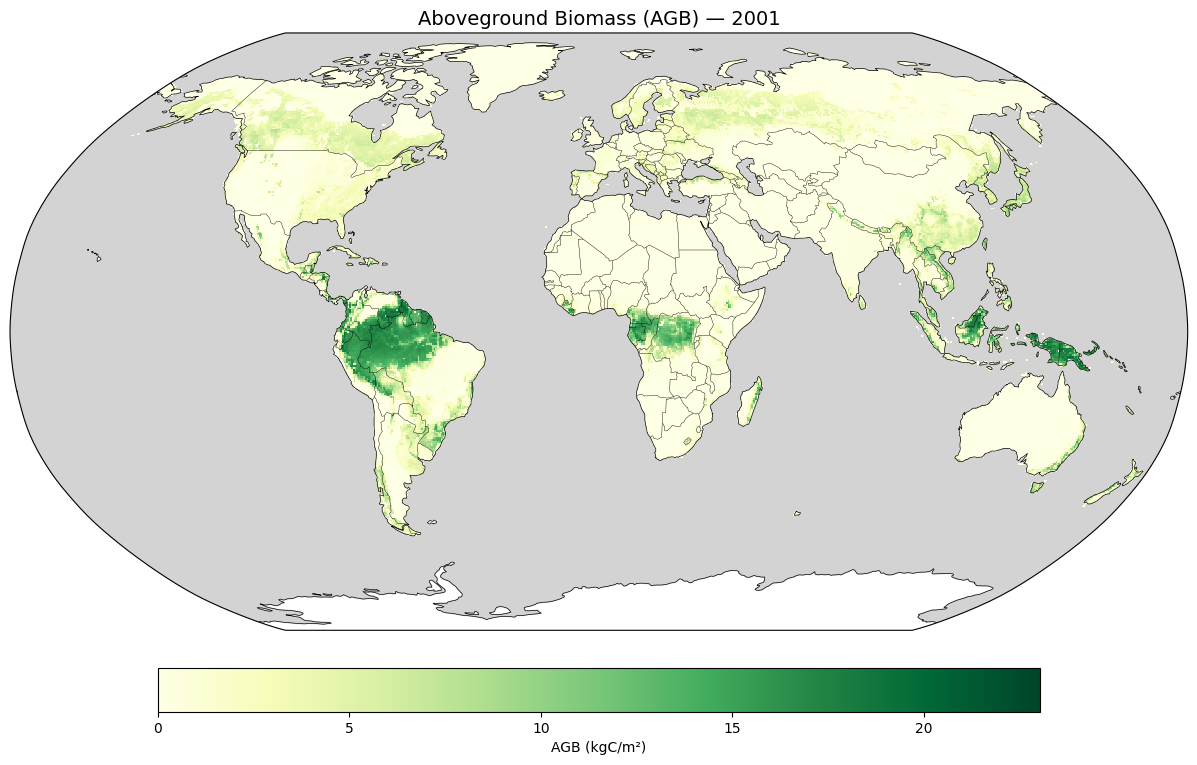

AGB stats — Min: 0.0000, Max: 23.0314, Mean: 1.6989


In [80]:
# PLOT ABOVEGROUND BIOMASS (AGB) — 2001
agb_2001 = 0.8 * cveg.sel(time="2001", method="nearest").load()    # aboveground biomass = 80% of total vegetation carbon

fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': ccrs.Robinson()})
agb_2001.plot(ax=ax, transform=ccrs.PlateCarree(),
              cmap='YlGn',
              cbar_kwargs={'label': 'AGB (kgC/m²)',
                           'orientation': 'horizontal',
                           'shrink': 0.6,
                           'pad': 0.05})
ax.add_feature(cfeature.OCEAN, color='lightgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_global()
ax.set_title("Aboveground Biomass (AGB) — 2001", fontsize=14)
plt.tight_layout()
plt.show()

print(f"AGB stats — Min: {float(agb_2001.min()):.4f}, Max: {float(agb_2001.max()):.4f}, Mean: {float(agb_2001.mean()):.4f}")

In [81]:
# PET (POTENTIAL EVAPOTRANSPIRATION) FUNCTION USING THORNTHWAITE METHOD
# Input:  temp_C — monthly temperature in Celsius (time, lat, lon)
# Output: pet    — monthly PET in mm/month (time, lat, lon)

def compute_pet_thornthwaite(temp_C):
    T_vals = xr.where(temp_C > 0, temp_C, 0.0)         # set negative temps to zero (no evaporation below freezing)
    I = ((T_vals / 5.0) ** 1.514).sum("time")           # annual heat index — sum of monthly heat index across 12 months
    a = 67.5e-8 * I**3 - 77.1e-6 * I**2 + 0.0179 * I + 0.492  # empirical exponent — function of heat index I
    pet = xr.where(
        temp_C <= 0, 0.0,                               # case 1: freezing — no evaporation
        xr.where(
            temp_C >= 26.5,
            -415.85 + 32.24 * temp_C - 0.43 * temp_C**2,  # case 2: high temp polynomial correction
            16.0 * ((10.0 * temp_C / I) ** a)              # case 3: standard Thornthwaite formula
        )
    )
    pet = pet.rename("pet_mm_month")                    # name the output variable
    pet.attrs["units"] = "mm/month"                     # assign units
    return pet

print("Thornthwaite PET function defined.")

Thornthwaite PET function defined.


In [82]:
# DRYNESS INDEX FUNCTION (D_bar)
# Direct translation of calcSiteDrynessIndex from ED source code (read_site_data.cc)
# Input:  pet    — monthly PET in mm/month (time, lat, lon)
#         precip — monthly precipitation in mm/month (time, lat, lon)
# Output: D_bar  — mean annual dryness index in mm (lat, lon)
def compute_Dbar_real(pet, precip):
    eps = 1e-12                                                              # small value to prevent division by zero
    dryness_index = [None] * 12                                              # list to store monthly dryness index
    dryness_index[0] = xr.zeros_like(pet.isel(time=0)).drop_vars("time", errors="ignore")  # January always zero (ED bug — month resets to 12 not 0)
    for month in range(1, 12):                                               # loop months 1-11 (February to December)
        pet_m      = pet.isel(time=month).drop_vars("time", errors="ignore")     # PET for current month
        precip_m   = precip.isel(time=month).drop_vars("time", errors="ignore")  # precip for current month
        precip_ann = precip_m * 12                                               # convert mm/month to mm/year to match ED threshold scale
        is_dry     = (pet_m / (precip_m + eps) > 1.0) & (precip_ann < 200.0)    # dry condition: PET > precip and precip < 200 mm/year (as in ED source code)
        di_cur     = xr.where(is_dry, dryness_index[month-1] + 30.0 * (pet_m - precip_m), 0.0)  # accumulate deficit if dry, else reset to zero
        dryness_index[month] = di_cur                                        # store monthly dryness index
    dryness_index_avg = sum(dryness_index) / 12.0                            # average over 12 months
    dryness_index_avg = dryness_index_avg.rename("D_bar")                    # name the output variable
    dryness_index_avg.attrs = {"units": "mm", "long_name": "ED dryness index"}  # assign units
    return dryness_index_avg

print("D_bar function defined.")

D_bar function defined.


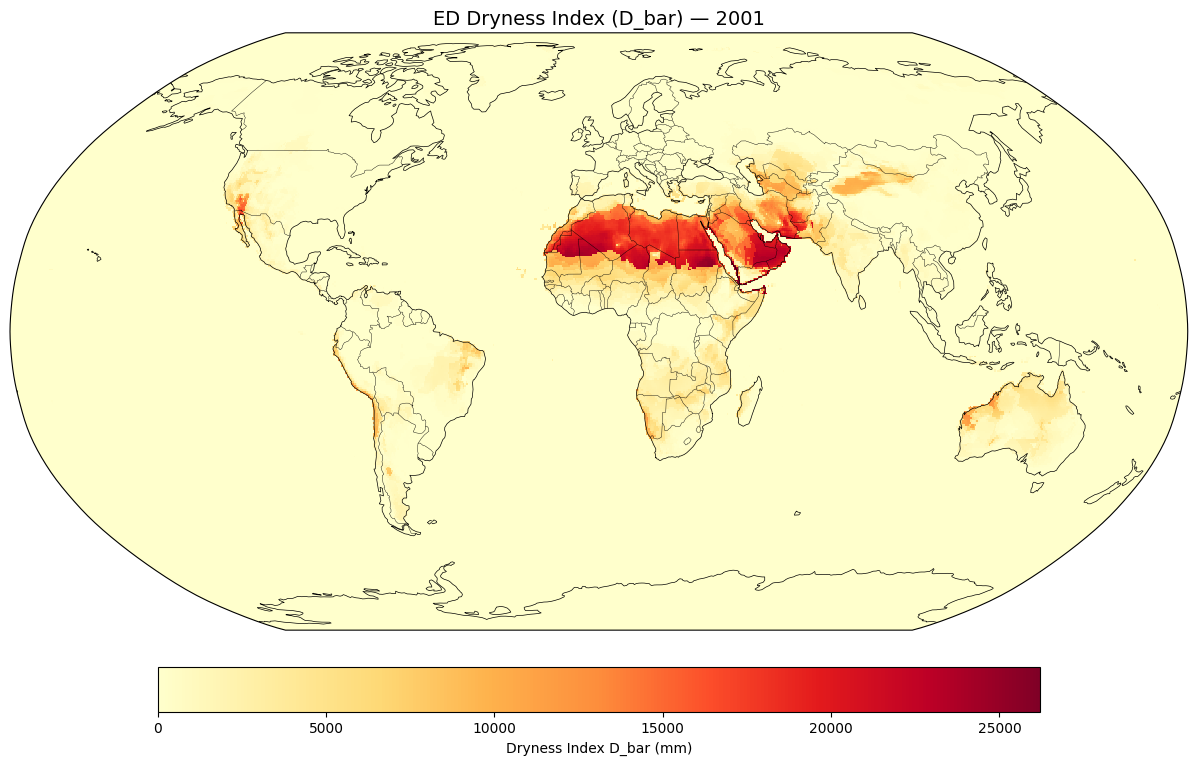

D_bar stats — Min: 0.00, Max: 26201.11, Mean: 509.21


In [83]:
# COMPUTE AND PLOT DRYNESS INDEX FOR 2001
ds_2001   = xr.open_dataset("v3.5/CRUJRA_v3.5_climate_2001.nc")
temp_C    = (ds_2001["temperature"] - 273.15).load()       # convert temperature from Kelvin to Celsius
precip    = ds_2001["precipitation"].load()                # load precipitation mm/month
ds_2001.close()

pet_2001  = compute_pet_thornthwaite(temp_C)               # compute PET using Thornthwaite
D_bar_2001 = compute_Dbar_real(pet_2001, precip)           # compute dryness index

# PLOT
fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': ccrs.Robinson()})
D_bar_2001.plot(ax=ax, transform=ccrs.PlateCarree(),
                cmap='YlOrRd',
                cbar_kwargs={'label': 'Dryness Index D_bar (mm)',
                             'orientation': 'horizontal',
                             'shrink': 0.6,
                             'pad': 0.05})
ax.add_feature(cfeature.OCEAN, color='lightgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_global()
ax.set_title("ED Dryness Index (D_bar) — 2001", fontsize=14)
plt.tight_layout()
plt.show()

print(f"D_bar stats — Min: {float(D_bar_2001.min()):.2f}, Max: {float(D_bar_2001.max()):.2f}, Mean: {float(D_bar_2001.mean()):.2f}")

In [84]:
# FIRE RISK FUNCTION - PLEASE READ CAREFULLY
# Direct translation from ED source code fire.cc lines 216-217
# Original ED parameters: normalization=30000, exponent=10
# These were calibrated for ED internal pot_soil_evap (mm/year scale, values up to 30000 mm/year)
# Thornthwaite PET operates at mm/month scale producing D_bar values up to ~2294 mm (95th percentile)
# Using original parameters produces near-zero fire risk everywhere due to scale mismatch
# Recalibration: normalization set to 95th percentile of D_bar (2294), exponent reduced to 3
# This preserves the spatial structure of the ED fire formulation while correcting for PET scale
# Input:  agb   — aboveground biomass kgC/m² (lat, lon)
#         D_bar — mean annual dryness index mm (lat, lon)
#         fp1   — fire parameter (default 1.0)
# Output: fire_risk — fire risk (lat, lon)
def compute_fire_risk_real(agb, D_bar, fp1=1.0):
    F_ignition = (D_bar / 2294.0) ** 3       # ignition probability — ED original: (D_bar/30000)^10, recalibrated here for Thornthwaite PET scale
    fire_risk  = (agb * fp1 * F_ignition).rename("fire_risk")    # fire risk = agb x ignition probability
    fire_risk.attrs = {"units": "kgC/m²", "long_name": "ED fire risk recalibrated for Thornthwaite PET"}
    return fire_risk

print("Fire risk function defined.")

Fire risk function defined.


In [85]:
# SEE D_BAR VALUES
# THIS IS A SANITY CHECK. Maximum value less than 30000, reason why I could not use the original normalization and expomemt, else the map would be blank everywhere
ds_test   = xr.open_dataset("v3.5/CRUJRA_v3.5_climate_2001.nc")
temp_test = (ds_test["temperature"] - 273.15).load()
precip_test = ds_test["precipitation"].load()
ds_test.close()

pet_test   = compute_pet_thornthwaite(temp_test)
D_bar_test = compute_Dbar_real(pet_test, precip_test)

print(f"D_bar Min:     {float(D_bar_test.min()):.2f}")
print(f"D_bar Max:     {float(D_bar_test.max()):.2f}")
print(f"D_bar Mean:    {float(D_bar_test.mean()):.2f}")
print(f"D_bar 95th:    {float(D_bar_test.quantile(0.95)):.2f}")
print(f"D_bar Sahel:   {float(D_bar_test.sel(lat=15, lon=10, method='nearest').values):.2f}")
print(f"D_bar Cerrado: {float(D_bar_test.sel(lat=-15, lon=-50, method='nearest').values):.2f}")
print(f"D_bar Australia: {float(D_bar_test.sel(lat=-25, lon=130, method='nearest').values):.2f}")

D_bar Min:     0.00
D_bar Max:     26201.11
D_bar Mean:    509.21
D_bar 95th:    2294.05
D_bar Sahel:   6361.85
D_bar Cerrado: 931.92
D_bar Australia: 784.31


In [68]:
# COMPUTE FIRE RISK FOR ALL YEARS (2001-2016)
fire_risk_years = []

for year in YEARS:
    ds_clim   = xr.open_dataset(f"v3.5/CRUJRA_v3.5_climate_{year}.nc")      # load climate for this year
    temp_C    = (ds_clim["temperature"] - 273.15).load()                     # convert Kelvin to Celsius
    precip    = ds_clim["precipitation"].load()                              # load precipitation
    ds_clim.close()

    agb_year  = 0.8 * cveg.sel(time=str(year), method="nearest").load()     # aboveground biomass = 80% of total vegetation carbon
    pet       = compute_pet_thornthwaite(temp_C)                             # compute PET using Thornthwaite
    D_bar     = compute_Dbar_real(pet, precip)                               # compute dryness index
    fire_risk = compute_fire_risk_real(agb_year, D_bar).load()               # compute fire risk
    fire_risk_years.append(fire_risk.copy())
    print(f"{year} done.")
    del temp_C, precip, agb_year, pet, D_bar, fire_risk                      # free memory

# AVERAGE FIRE RISK OVER ALL YEARS
fire_risk_mean = sum(fire_risk_years) / len(fire_risk_years)                 # mean fire risk 2001-2016
fire_risk_mean = fire_risk_mean.rename("fire_risk_mean")
print("All years done.")

2001 done.
2002 done.
2003 done.
2004 done.
2005 done.
2006 done.
2007 done.
2008 done.
2009 done.
2010 done.
2011 done.
2012 done.
2013 done.
2014 done.
2015 done.
2016 done.
All years done.


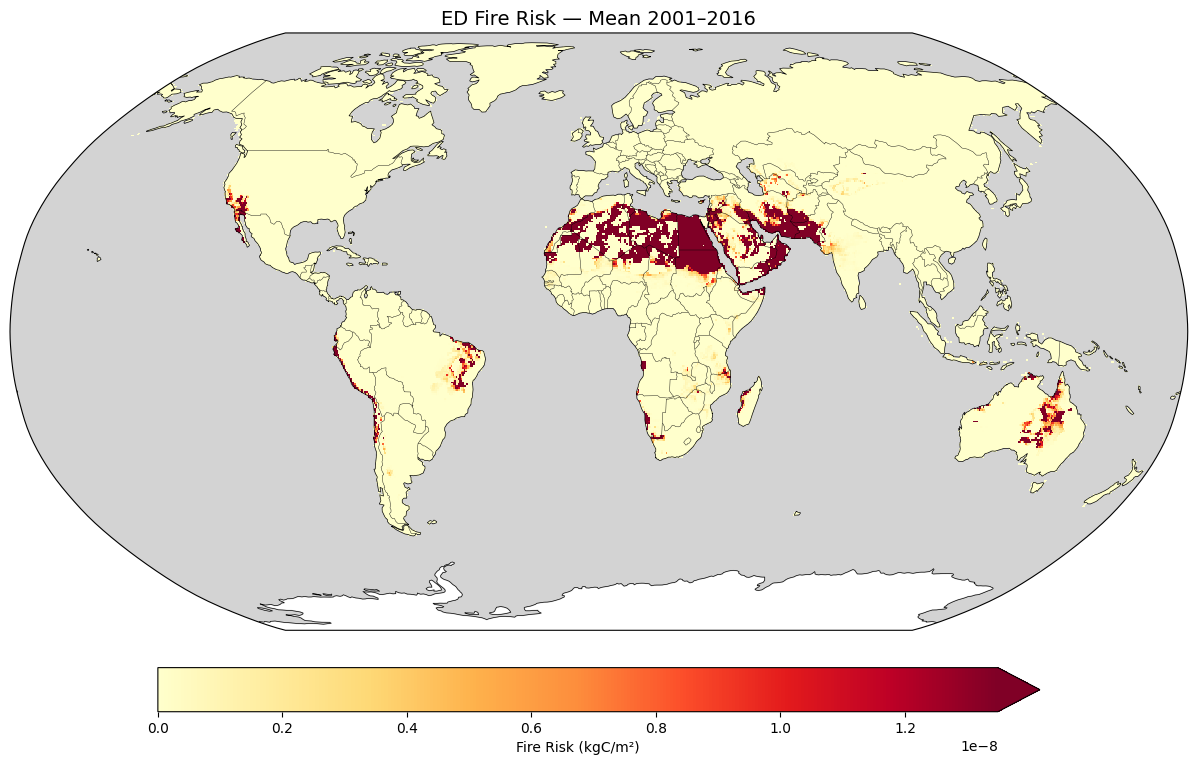

Fire risk stats — Min: 0.0000, Max: 0.0012, Mean: 0.0000, 95th: 0.0000


In [69]:
# PLOT MEAN FIRE RISK 2001-2016
fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': ccrs.Robinson()})
fire_risk_mean.plot(ax=ax, transform=ccrs.PlateCarree(),
                    cmap='YlOrRd',
                    vmin=0,
                    vmax=float(fire_risk_mean.quantile(0.95)),           # cap colorbar at 95th percentile
                    cbar_kwargs={'label': 'Fire Risk (kgC/m²)',
                                 'orientation': 'horizontal',
                                 'shrink': 0.6,
                                 'pad': 0.05})
ax.add_feature(cfeature.OCEAN, color='lightgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_global()
ax.set_title("ED Fire Risk — Mean 2001–2016", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Fire risk stats — Min: {float(fire_risk_mean.min()):.4f}, Max: {float(fire_risk_mean.max()):.4f}, Mean: {float(fire_risk_mean.mean()):.4f}, 95th: {float(fire_risk_mean.quantile(0.95)):.4f}")

In [60]:
# DIAGNOSE D_BAR VALUES
ds_test   = xr.open_dataset("v3.5/CRUJRA_v3.5_climate_2001.nc")
temp_test = (ds_test["temperature"] - 273.15).load()
precip_test = ds_test["precipitation"].load()
ds_test.close()

pet_test   = compute_pet_thornthwaite(temp_test)
D_bar_test = compute_Dbar_real(pet_test, precip_test)

print(f"D_bar Min:     {float(D_bar_test.min()):.2f}")
print(f"D_bar Max:     {float(D_bar_test.max()):.2f}")
print(f"D_bar Mean:    {float(D_bar_test.mean()):.2f}")
print(f"D_bar 95th:    {float(D_bar_test.quantile(0.95)):.2f}")
print(f"D_bar Sahel:   {float(D_bar_test.sel(lat=15, lon=10, method='nearest').values):.2f}")
print(f"D_bar Cerrado: {float(D_bar_test.sel(lat=-15, lon=-50, method='nearest').values):.2f}")
print(f"D_bar Australia: {float(D_bar_test.sel(lat=-25, lon=130, method='nearest').values):.2f}")

D_bar Min:     0.00
D_bar Max:     26201.11
D_bar Mean:    509.21
D_bar 95th:    2294.05
D_bar Sahel:   6361.85
D_bar Cerrado: 931.92
D_bar Australia: 784.31


In [61]:
pet_test2   = compute_pet_thornthwaite(temp_test)
D_bar_test2 = compute_Dbar_real(pet_test2, precip_test)

print(f"D_bar Min:     {float(D_bar_test2.min()):.2f}")
print(f"D_bar Max:     {float(D_bar_test2.max()):.2f}")
print(f"D_bar Mean:    {float(D_bar_test2.mean()):.2f}")
print(f"D_bar 95th:    {float(D_bar_test2.quantile(0.95)):.2f}")
print(f"D_bar Sahel:   {float(D_bar_test2.sel(lat=15, lon=10, method='nearest').values):.2f}")
print(f"D_bar Cerrado: {float(D_bar_test2.sel(lat=-15, lon=-50, method='nearest').values):.2f}")
print(f"D_bar Australia: {float(D_bar_test2.sel(lat=-25, lon=130, method='nearest').values):.2f}")

D_bar Min:     0.00
D_bar Max:     26201.11
D_bar Mean:    509.21
D_bar 95th:    2294.05
D_bar Sahel:   6361.85
D_bar Cerrado: 931.92
D_bar Australia: 784.31
